# 2 - Training U-Net for Gap-Filling (Generic - Streaming)

**Self-supervised streaming training pipeline** for any Level-3 ocean variable.

This notebook trains a U-Net to fill gaps in satellite ocean observations using **xbatcher streaming** to keep memory bounded. Works for:
- Chlorophyll-a (PACE, Copernicus, CMEMS)
- Sea surface temperature
- Any other gridded ocean variable with cloud/missing data

## Key Features

- **Streaming workflow**: Zarr → xarray/Dask → xbatcher → TensorFlow
- **Memory-bounded**: Never loads full dataset into RAM
- **Spatial chunking**: 40×56 tiles (or configurable)
- **Generic target variable**: Not hardcoded to chlorophyll
- **Self-supervised**: No gap-free truth needed  
- **Synthetic clouds**: Temporally-correlated fake gaps for training/eval

## Workflow

```
Zarr (on-disk)
  ↓ xr.open_zarr with chunks
Lazy xarray/Dask Dataset
  ↓ prepare_model_data (crops to U-Net multiple, no .load())
Lazy standardized channels
  ↓ xbatcher.BatchGenerator
Spatial tiles (time × 40×56)
  ↓ make_tf_gen → tf.data.Dataset
Training batches
  ↓
model.fit()
```

## Setup

### packages

In [3]:
%pip install -e ..

%load_ext autoreload
%autoreload 2

Obtaining file:///home/jovyan/mindthegap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mindthegap (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.2.0-0.editable-py3-none-any.whl size=5715 sha256=b994add7070757d9b1d4760f6724b94d52e1f8487adbf580d413bb11119deb33
  Stored in directory: /tmp/pip-ephem-wheel-cache-ouy0nadb/wheels/bf/33/56/bda8a265cbf6abb8b49f20ef4e8f99a5cafc428b704405201e
Successfully built mindthegap
  Attempting uninstall: mindthegap
    Found existing installation: mindthegap 0.2.0
    Uninstalling mindthegap-0.2.0:
      Successfully uninstalled mindthegap-0.2.0
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import mindthegap as mtg

In [2]:
!pip install -qU "icechunk>=2" "earthaccess>=0.15"

In [4]:
!pip install -qU boto3 botocore s3transfer

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.58 requires botocore==1.43.58, but you have botocore 1.43.67 which is incompatible.
aiobotocore 2.25.2 requires botocore<1.40.71,>=1.40.46, but you have botocore 1.43.67 which is incompatible.


### GPU set up

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Reduce TensorFlow verbosity

import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as plt
import mindthegap as mtg

# TensorFlow automatically uses CPU when no GPU is available.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute device: {'GPU' if gpus else 'CPU'}")
print(f"GPUs available: {len(gpus)}")

2026-08-13 19:41:21.783313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786650081.802023    3297 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786650081.808430    3297 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786650081.822546    3297 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786650081.822569    3297 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786650081.822571    3297 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.1
Compute device: GPU
GPUs available: 1


## 0. Options

`options` is the pipeline configuration. Options is the single, canonical config for this run.

smoke_test propagates the fast-run settings (few epochs) into options.fit.

## 1. Load Your Data

Load your xarray Dataset with **time, lat, lon** dimensions.

### Requirements:
- Target variable (e.g., `chlor_a`, `sst`, `analysed_sst`)
- Cloud/missing flag variable (1 = cloud/missing, 0 = valid data)
- Land flag variable (1 = land, 0 = ocean)
- Optional: Additional predictor variables (SST, winds, salinity, etc.)

### Data Source Examples:

In [8]:
# Import the local checkout when running this notebook from the repository.
dataset = "globcolour"  # pace, globcolour, indian-ocean, or synthetic
region = "arabian sea"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = None

dataset = "indian-ocean"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2000", "12-31-2000")

dataset = "io-shared-public"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2010", "01-01-2020")

In [10]:
# Load the data. demo_data configures options.data in place from the
# dataset (variable names, bounds, time range) and returns only ds.
options = mtg.Options.default(smoke_test=False)
ds = mtg.demo_data(
    dataset,
    options,
    region=region,
    time_slice=time_slice,
    smoke_test=False,
)
print(f"Dimensions: {dict(ds.sizes)}")


Selected dataset: IO rechunkded in shared-public
Dimensions: {'time': 3653, 'lat': 169, 'lon': 241}


## Set up options

In [11]:
# options was created and configured by demo_data above.
# Adjust any run settings here as needed.


In [12]:
# log-transform CHL since it is 0-bounded (set False for e.g. SST).
options.data.log_target = True

# demo_data already resolved the gridder from the dataset. Override the
# tile size / time chunk / batch size here to match the earlier run.
options.gridder.tile_size = (64, 64)
options.gridder.time_chunk = 100
options.fit.batch_size = 8


## 2. Build Standardized Training data

Use `prepare_model_data()` to create standardized predictors **without loading data into memory**. It crops the spatial dimensions to a U-Net-compatible multiple internally.

## Training and validation dates

Select the dates to use for training and validation

In [13]:
# Choose the training and validation dates. 
options.split.train_fraction=0.85
options.split.val_fraction=0.15
options.split.n_days=500

# For fixed windows instead, set options.split.method = "manual" and pass
# train_slice / val_slice:
#   options.split.method = "manual"
#   mtg.train_validation_dates(
#       ds.time, options,
#       train_slice=slice("1997-01-01", "2000-01-01"),
#       val_slice=slice("2000-01-02", "2001-01-01"),
#   )

mtg.train_validation_dates(ds.time, options);


Split method: random (train=425, val=75 dates)
Training period: 2010-01-08 to 2019-12-26


## Build lazy standardized dataset

* add n-prev and n-next targets as inputs
* add features (optional) as inputs; standardize
* add flags (land, real cloud, fake cloud)
* rename the target; standardize and log (optional)

In [14]:
# To add spherical lat/lon features, set options.data.add_geo = True 
#
# The synthetic-cloud configuration is canonical on options.data. It defaults
# to options.data.cloud_mode = "synthetic_bank", which draws training clouds
# from a small precomputed, downloadable bank. Set options.data.cloud_mode = "synthetic" to
# instead generate clouds on the fly (the original, more expensive path).
options.data.cloud_mode = "synthetic_bank" 
ds_std = mtg.prepare_model_data(ds, options, mode="train")
ds_std.load()

Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 53), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})


KeyboardInterrupt: 

## Problem with the IO data

There is a gap between land and where the measurements start. That should be fixed.

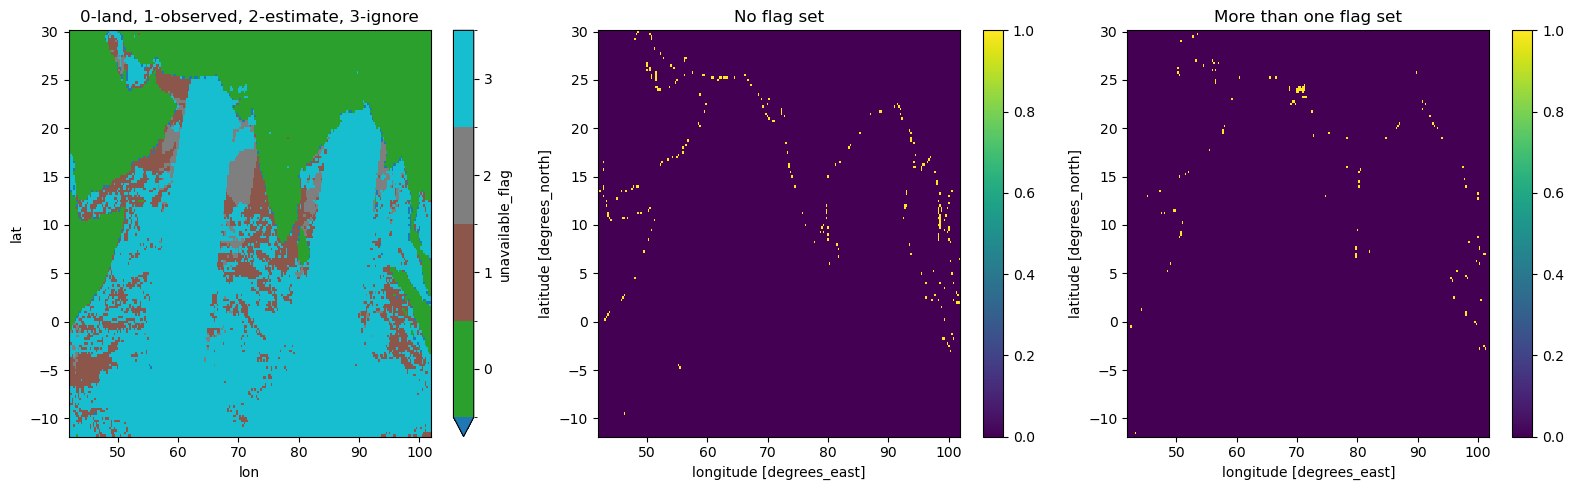

In [16]:
import matplotlib.pyplot as plt
import xarray as xr

t = 20

land = ds_std.land_flag.isel(time=t)
observed = ds_std.observed_flag.isel(time=t)
estimate = ds_std.estimate_flag.isel(time=t)
unavailable = ds_std.unavailable_flag.isel(time=t)

# Count how many flags are set at each pixel
flag_count = land + observed + estimate + unavailable

# Category map:
# 0 = land
# 1 = observed
# 2 = estimate
# 3 = unavailable
category = xr.full_like(land, fill_value=-1, dtype="int8")
category = xr.where(land == 1, 0, category)
category = xr.where(observed == 1, 1, category)
category = xr.where(estimate == 1, 2, category)
category = xr.where(unavailable == 1, 3, category)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

category.plot(
    ax=axes[0],
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap="tab10",
    cbar_kwargs={"ticks": [0, 1, 2, 3]},
)
axes[0].set_title("0-land, 1-observed, 2-estimate, 3-ignore")

(flag_count == 0).plot(ax=axes[1])
axes[1].set_title("No flag set")

(flag_count > 1).plot(ax=axes[2])
axes[2].set_title("More than one flag set")

plt.tight_layout()

In [22]:
land = ds_std.land_flag.isel(time=t).astype("int8").compute()
observed = ds_std.observed_flag.isel(time=t).astype("int8").compute()
estimate = ds_std.estimate_flag.isel(time=t).astype("int8").compute()
unavailable = ds_std.unavailable_flag.isel(time=t).astype("int8").compute()

flag_count = land + observed + estimate + unavailable

combo = (
    1 * land
    + 2 * observed
    + 4 * estimate
    + 8 * unavailable
)

vals, counts = np.unique(
    combo.where(flag_count > 1).values,
    return_counts=True,
)

names = {
    3: "land + observed",
    5: "land + estimate",
    6: "observed + estimate",
    7: "land + observed + estimate",
    9: "land + unavailable",
    10: "observed + unavailable",
    11: "land + observed + unavailable",
    12: "estimate + unavailable",
    13: "land + estimate + unavailable",
    14: "observed + estimate + unavailable",
    15: "all four",
}

for v, n in zip(vals, counts):
    if not np.isnan(v):
        print(f"{names[int(v)]:35s} {n}")

land + observed                     51
land + unavailable                  69


## 3. Create xbatcher Streaming Pipeline

Use `mtg.make_xbatcher()` to create tile generators, then wrap with `mtg.make_tf_gen()` for TensorFlow.

In [17]:
# Build the streaming train/validation TensorFlow datasets in one call.
# make_generator splits ds_std using options.split, tiles with options.gridder,
# reads the channel order/target from options.data, and batches with
# options.fit. It returns the datasets and the steps-per-epoch.

train_dataset, val_dataset, train_steps, val_steps = mtg.make_generator(
    ds_std,
    options,
)


Streaming datasets ready (batch size 8): steps per epoch train=180, val=45


## 4. Build U-Net Model

Fully-convolutional U-Net that can accept any spatial size (trains on 40×56, can predict on full domain).

In [18]:
# Build U-Net (fully-convolutional). The channel count comes from the resolved
# configuration; compilation is handled by mtg.fit_model using options.fit.
# mtg.UNet prints its input/output shapes and channel order when verbose,
# controlled by the global options.verbose.
num_channels = len(options.data.input_names)
model = mtg.UNet(
    (None, None, num_channels),
    verbose=options.verbose,
    tile_size=options.gridder.tile_size,
    input_names=options.data.input_names,
)

# model.summary()



Model input shape: (batch, 64, 64, 9)
Model output shape: (batch, 64, 64, 1)

Input names: ['observed_target', 'observed_target_m1', 'observed_target_p1', 'day_sin', 'day_cos', 'estimate_flag', 'unavailable_flag', 'observed_flag', 'land_flag']


## 5. Train with Streaming Data

Train using xbatcher streaming—data is loaded one tile at a time, keeping memory bounded.

In [19]:
# Train. mtg.fit_model compiles the model using options.fit (optimizer,
# learning rate, loss), installs EarlyStopping with options.fit.patience, and
# prints progress when options.verbose is True.
history = mtg.fit_model(
    model,
    train_dataset,
    options,
    validation_data=val_dataset,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
)


Starting training: epochs=50, batch_size=8, patience=10
Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 0.0569 - mae: 0.1186 - val_loss: 0.0187 - val_mae: 0.0607
Epoch 2/50
114/180 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0224 - mae: 0.0727

KeyboardInterrupt: 

## 6. Visualize Training History

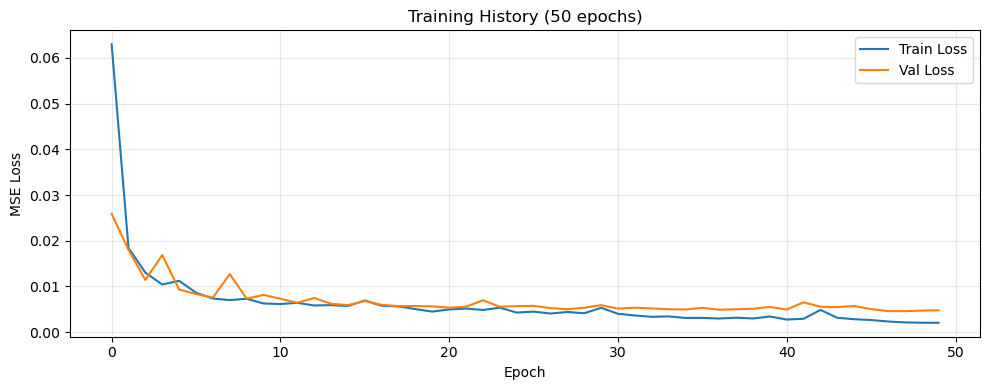


Best epoch: 48
Best val_loss: 0.004605


In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

epochs_run = len(history.history['loss'])
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training History ({epochs_run} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

## 7. Test Prediction (Full Domain)

Load one test frame and predict on the full domain to verify the model works.

In [22]:
# Pick a test day: the last date in the record that was not used for training
# or validation, falling back to the final available day.
used = set(options.split.train_dates) | set(options.split.val_dates)
available = [str(pd.to_datetime(t).date()) for t in ds_std.time.values]
unused = [d for d in available if d not in used]
test_date = unused[-1] if unused else available[-1]
print(f"Test prediction date: {test_date}")

# Select and load test frame
ds_test = ds_std.sel(time=test_date).load()

# Stack channels in the resolved order.
X_test = np.stack(
    [np.nan_to_num(ds_test[ch].values, nan=0.0) for ch in options.data.input_names],
    axis=-1,
).astype('float32')
X_test = X_test[np.newaxis, ...]  # Add batch dimension

print(f"Test input shape: {X_test.shape}")

# Predict (fully-convolutional model handles any size)
y_pred = model(X_test, training=False).numpy()[0, :, :, 0]

# Unstandardize using the resolved target statistics.
y_pred_orig = y_pred * options.data.target_std + options.data.target_mean

print(f"Prediction shape: {y_pred_orig.shape}")
print(f"Prediction range: [{np.nanmin(y_pred_orig):.4f}, {np.nanmax(y_pred_orig):.4f}]")
print("\n\u2713 Model successfully predicts on full domain")

Test prediction date: 2000-12-31
Test input shape: (1, 168, 240, 9)
Prediction shape: (168, 240)
Prediction range: [-3.1369, 2.4688]

✓ Model successfully predicts on full domain


## Making a prediction

Currently the model does not use a custom loss and under clouds, the target is 0 (nan replaced with 0). So the model learns that if there is a real cloud (real_cloud_flag is 1) then predict 0 always. The model also learns that if synthetic _cloud = 0 and real_cloud = 0, then there is a value in masked_target and use that. If synthetic _cloud = 1 and real_cloud = 0, then there is always a 0 in masked_target (non-informative) so make an estimate from the other input variables. 

Soo, that means if we make a prediction from ds_test, it will have 0s whereever there are real clouds and it will only make estimates under the synthetic clouds.

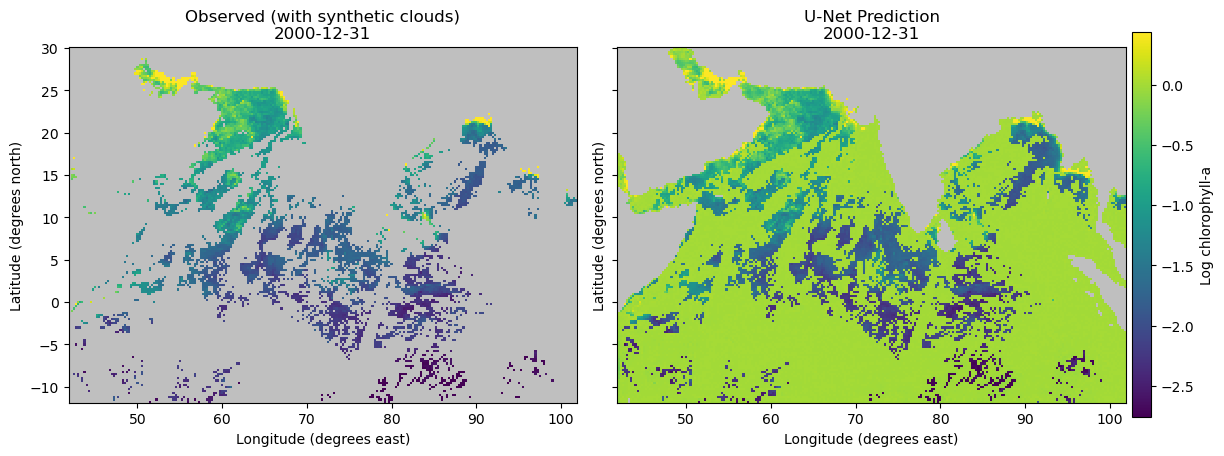

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Put observations in the same unstandardized units as the prediction.
observed = ds_test['observed_target'].values * options.data.target_std + options.data.target_mean
land = ds_test['land_flag'].values.astype(bool)
observed = np.ma.masked_where(land | ~np.isfinite(observed), observed)
prediction = np.ma.masked_where(land | ~np.isfinite(y_pred_orig), y_pred_orig)

# Use geographic coordinates and one robust scale for both panels.
vmin, vmax = np.nanpercentile(observed.filled(np.nan), [2, 98])
plot_kwargs = dict(cmap='viridis', shading='auto', vmin=vmin, vmax=vmax)
longitude = ds_test['lon'].values
latitude = ds_test['lat'].values

axes[0].set_facecolor('0.75')
axes[0].pcolormesh(longitude, latitude, observed, **plot_kwargs)
axes[0].set_title(f'Observed (with synthetic clouds)\n{test_date}')

axes[1].set_facecolor('0.75')
im = axes[1].pcolormesh(longitude, latitude, prediction, **plot_kwargs)
axes[1].set_title(f'U-Net Prediction\n{test_date}')

for ax in axes:
    ax.set_xlabel('Longitude (degrees east)')
    ax.set_ylabel('Latitude (degrees north)')
    ax.set_aspect('equal')

color_label = 'Log chlorophyll-a' if options.data.log_target else 'Chlorophyll-a'
plt.colorbar(im, ax=axes, label=color_label, fraction=0.02)
fig.subplots_adjust(wspace=0.08, right=0.88)
plt.show()


## 8. Save Model

Save the trained model for later use.

In [25]:
# Everything the bundle needs is already resolved on options.data, so the
# metadata and the fitting pipeline cannot diverge. Save the complete resolved
# Options with the bundle.
from pathlib import Path
region = {"lat": list(options.data.lat_bounds), "lon": list(options.data.lon_bounds)}
bundle_path = Path("../models") / f"{dataset}-unet-bundle"
metadata_path = mtg.create_model_bundle_metadata(
    bundle_path,
    model_name=f"{options.data.source} U-Net gap filler",
    dataset_name=options.data.source,
    product_id=options.data.product_id,
    region=region,
    training_period=options.split.training_period(),
    input_names=options.data.input_names,
    target_name=options.data.target_name,
    target_units=options.data.target_units,
    expected_input_shape=list(model.input_shape),
    transforms=options.data.transforms,
    standardization=options.data.standardization,
    missing_value_handling=options.data.missing_value_handling,
    limitations=(
        "Validated only for the documented product, region, training period, "
        "channel order, and preprocessing configuration."
    ),
    options=options,
    overwrite=True,
)
print(f"Metadata saved to: {metadata_path}")


Metadata saved to: ../models/io-shared-public-unet-bundle/model_metadata.yaml


### Stop and review the metadata

Open the `model_metadata.yaml` file printed above. Check the dataset, region, training period, input channel order, transforms, and standardization values. **Do not run the next cell until the metadata is correct.**

In [26]:
mtg.save_model_bundle(
    model,
    bundle_path,
    overwrite=True,
)
print(f"✓ Model bundle saved to: {bundle_path}")

✓ Model bundle saved to: ../models/io-shared-public-unet-bundle


In [27]:
# Verify that the released artifact loads without rebuilding the U-Net.
loaded_model, loaded_metadata = mtg.load_model_bundle(bundle_path)
round_trip_input = X_test[:1]
expected = model(round_trip_input, training=False).numpy()
actual = loaded_model(round_trip_input, training=False).numpy()
np.testing.assert_allclose(actual, expected, rtol=1e-6, atol=1e-6)
assert [item["name"] for item in loaded_metadata["inputs"]] == options.data.input_names
print("✓ Bundle reload produced equivalent predictions")


Data loaded for this model with: demo_data(dataset='io-shared-public', region='indian ocean', time_slice=slice('01-01-2000', '12-31-2000'))
✓ Bundle reload produced equivalent predictions
